<a href="https://colab.research.google.com/github/aaaraafaat/Data-Science/blob/main/Big_Data_Map_Reduce_Counting_Words.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from collections import defaultdict

# ==========================================
# 1. MAP FUNCTION
# ==========================================
def map_words(text):
    """Splits text into words and assigns a count of 1 to each."""
    words = text.lower().split()
    mapped_values = []

    for word in words:
        # Clean basic punctuation for better counting
        clean_word = word.strip(".,!?\"'")
        if clean_word:
            mapped_values.append((clean_word, 1))

    return mapped_values

In [ ]:

# ==========================================
# 2. REDUCE FUNCTION
# ==========================================
def reduce_counts(word, counts):
    """Sums up the list of 1s for a specific word."""
    return word, sum(counts)

In [8]:
# ==========================================
# 3. EXECUTION & FILE HANDLING
# ==========================================

# B. Read the Input File
with open('Arafat.txt', 'r') as f:
    text_data = f.read()

# C. Execute MAP
mapped_data = map_words(text_data)

# D. Execute SHUFFLE & SORT (Grouping by word)
grouped_data = defaultdict(list)
for word, count in mapped_data:
    grouped_data[word].append(count)

# E. Execute REDUCE
final_results = []
for word, counts in grouped_data.items():
    final_results.append(reduce_counts(word, counts))

# F. Save and Print the Output Result (Requirement 1 & 3)
print("--- MapReduce Word Count Results ---")
with open('output.txt', 'w') as f:
    for word, total_count in final_results:
        result_line = f"{word}: {total_count}"
        f.write(result_line + "\n")
        print(result_line)

--- MapReduce Word Count Results ---
tdl-b: 8
system: 4
architecture: 1
the: 80
data: 11
link: 18
can: 2
be: 4
built: 1
around: 2
a: 18
tdl: 9
application: 4
(data: 1
processor): 1
that: 6
sits: 3
between: 3
two: 3
boundaries: 2
on: 5
one: 4
side: 3
is: 18
radio: 10
mesh: 10
—: 21
physical: 1
layer: 2
manet: 1
carrying: 2
rf: 5
transmission: 2
other: 2
waveform/message: 1
standard: 2
itself: 1
encryption: 8
at: 3
levels: 1
has: 1
built-in: 1
aes: 2
fixed: 1
in: 8
hardware: 2
it: 9
only: 3
demonstrated: 1
not: 11
modified: 1
matters: 1
operationally: 1
lives: 1
message: 11
level: 1
and: 20
this: 4
must: 3
flexible: 3
user-configurable: 1
with: 12
baf-controlled: 1
keys: 2
independent: 1
of: 7
vendor's: 1
aircraft: 2
integration: 2
goes: 1
through: 4
icd: 17
aircraft's: 1
mission: 2
generates: 1
fixed-format: 1
(ff): 1
messages: 7
interface: 5
control: 1
document: 1
(icd): 1
defines: 3
exactly: 2
which: 4
exist: 2
how: 5
they're: 1
structured: 1
means: 1
resetting: 2
really: 1
any: 1
cha

--- Organized Data Table ---


,Word,Frequency
3,the,80
26,—,21
56,and,20
23,is,18
10,a,18
...,...,...
518,latency,1
517,measure,1
516,retest,1
515,bench,1



--- Visual Bar Chart ---


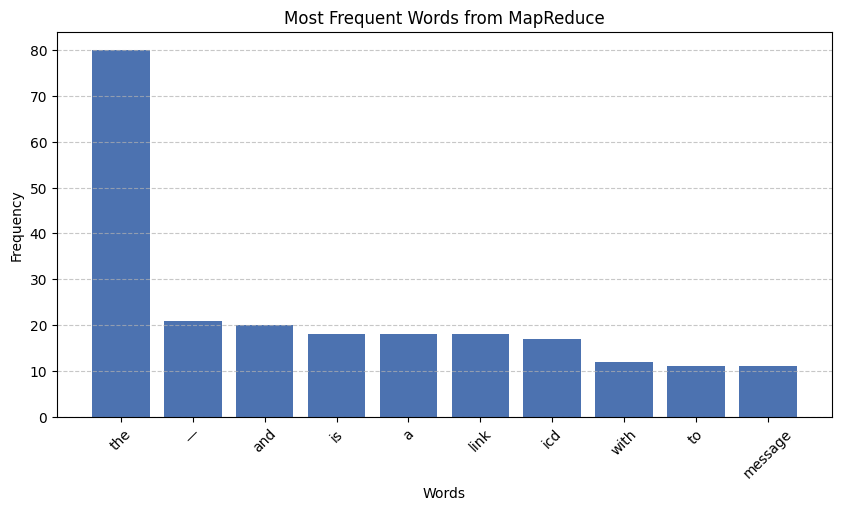

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# VISUALIZATION & ORGANIZATION
# ==========================================

# 1. Convert the results into a Pandas DataFrame (a structured table)
df = pd.DataFrame(final_results, columns=['Word', 'Frequency'])

# 2. Sort the table from highest frequency to lowest
df_sorted = df.sort_values(by='Frequency', ascending=False)

# 3. Display the clean, organized table
# (Colab automatically renders DataFrames as beautiful interactive tables)
print("--- Organized Data Table ---")
display(df_sorted)

# 4. Create a Bar Chart for the Top 10 most frequent words
print("\n--- Visual Bar Chart ---")
plt.figure(figsize=(10, 5))

# Get just the top 5 or 10 words to keep the chart clean
top_words = df_sorted.head(10)

# Plot the bars
plt.bar(top_words['Word'], top_words['Frequency'], color='#4C72B0')

# Add labels and formatting to make it easy to read
plt.title('Most Frequent Words from MapReduce')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45) # Tilts the words so they don't overlap
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the final graph
plt.show()